# Introduction to JAX: From NumPy to Real-Time MPPI

**What is JAX?**
> JAX is a Python library for accelerator-oriented array computation and program transformation, designed for high-performance numerical computing and large-scale machine learning.
>
> Source: https://github.com/jax-ml/jax

At a high level, you can think of JAX as a "numpy+Pytorch high-performance computing package", with three core features:  
- **`jit`** -- compile functions to run on GPU/CPU via XLA
- **`vmap`** -- vectorize over batch dimensions (CPU, GPU, & TPU)
- **`grad`** -- automatic differentiation

For Roboracer, this means: write clean, readable, single-sample math, then let JAX handle the compilation, batching, and differentiation to hit real-time control rates.

**Our running example:** We will build an **MPPI** (Model Predictive Path Integral) controller from scratch using a **kinematic bicycle model**. MPPI is a natural fit because it is embarrassingly parallel (thousands of sampled rollouts) and sequential within each rollout (dynamics propagation over a horizon), so it exercises every major JAX feature.

| Section | JAX Concept | What it does for MPPI |
|---|---|---|
| 1 | `jax.numpy` | Write the dynamics and cost in familiar NumPy syntax |
| 2 | `jax.jit` | Compile the dynamics step for speed |
| 3 | `jax.lax.scan` | Replace the Python for-loop over the horizon with a compiled loop |
| 4 | `jax.vmap` | Parallelize over thousands of sampled rollouts |
| 5 | Composition | `jit(vmap(scan(...)))` -- the full compiled, batched pipeline |
| 6 | `jax.grad` | Free Jacobians for MPC linearization |

## Setup

In [ ]:
import jax
import jax.numpy as jnp
import jax.lax as lax
from jax import jit, vmap, grad, jacobian, value_and_grad
import numpy as np
import matplotlib.pyplot as plt
import time

# Check backend
print(f"JAX version: {jax.__version__}")
print(f"Backend:     {jax.default_backend()}")
print(f"Note: Backend will be CPU on Colab if a GPU runtime is not chosen.")

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

JAX version: 0.7.2
Backend:     gpu
Note: Backend will be CPU on Colab if a GPU runtime is not chosen.


---
## Section 1 -- `jax.numpy`: The Familiar Starting Point

`jax.numpy` is a near-drop-in replacement for NumPy. Most functions share the same name and signature.

In [ ]:
# Array creation -- same API as NumPy
a = jnp.array([1.0, 2.0, 3.0])
b = jnp.zeros((3, 3))
c = jnp.linspace(0, 2 * jnp.pi, 50)

# Math -- same API
result = jnp.sin(c)

print(f"a       = {a}")
print(f"sin(c)  = {result[:5]}...")  # first 5 elements
print(f"dtype   = {a.dtype}")        # float32 by default!

a       = [1. 2. 3.]
sin(c)  = [0.         0.12787716 0.2536546  0.37526703 0.49071756]...
dtype   = float32


### Three Key Differences from NumPy

**1. Immutable arrays** -- you cannot do in-place mutation:

In [ ]:
# NumPy style (DOES NOT WORK in JAX):
# a[0] = 99.0  # <- TypeError!

# JAX style -- .at[].set() returns a NEW array:
a_new = a.at[0].set(99.0)
print(f"original: {a}")
print(f"updated:  {a_new}")

original: [1. 2. 3.]
updated:  [99.  2.  3.]


**2. Explicit random number generation** -- no global state like `np.random`. You manage keys explicitly, which is essential for reproducibility and parallelism:

In [ ]:
key = jax.random.PRNGKey(0)           # create a root key
key, subkey = jax.random.split(key)   # split to get a usable subkey
noise = jax.random.normal(subkey, shape=(5,))
print(f"noise = {noise}")

# Every time you need randomness, split the key:
key, sk1, sk2 = jax.random.split(key, 3)
print(f"sample 1: {jax.random.normal(sk1, (2,))}")
print(f"sample 2: {jax.random.normal(sk2, (2,))}")

noise = [-2.4424558  -2.0356805   0.20554423 -0.3535502  -0.76197404]
sample 1: [-1.2574775 -0.4016044]
sample 2: [-0.74384534  0.6374782 ]


**3. Default dtype is `float32`**, not `float64`. This is optimal for GPU computation but be mindful of numerical precision.

You can overwrite this by setting `jax.config.update("jax_enable_x64", True)`

In [ ]:
jax.config.update("jax_enable_x64", True)

# Array created as float64
a = jnp.array([1.0, 2.0, 3.0], dtype=jnp.float32)
b = jnp.zeros((3, 3), dtype=jnp.float64)
print(f"b.dtype   = {b.dtype}")        # float64 by default!
print(f"a.dtype   = {a.dtype}")        # float32 enforced

# Disable it back as we won't need the extra precision
jax.config.update("jax_enable_x64", False)

b.dtype   = float64
a.dtype   = float32


### MPPI Application: Kinematic Bicycle Model

We define the dynamics model that we will use throughout the entire tutorial. This is a standard kinematic bicycle model.

$$
\begin{aligned}
x_{t+1} &= x_t + v_t \cos(\theta_t) \, \Delta t \\
y_{t+1} &= y_t + v_t \sin(\theta_t) \, \Delta t \\
\theta_{t+1} &= \theta_t + \frac{v_t}{L} \tan(\delta_t) \, \Delta t \\
v_{t+1} &= v_t + a_t \, \Delta t
\end{aligned}
$$

State: $[x, y, \theta, v]$, Control: $[\delta, a]$ (steering angle, acceleration).
We'll use euler integration for simplicity.

In [ ]:
# Vehicle parameters
L = 0.33   # wheelbase [m] (F1TENTH)
DT = 0.05  # timestep [s]

def dynamics(state, control, dt=DT):
    "Kinematic bicycle model -- single step.  state: (4,), control: (2,)"
    x, y, theta, v = state
    delta, a = control

    x_next     = x + v * jnp.cos(theta) * dt
    y_next     = y + v * jnp.sin(theta) * dt
    theta_next = theta + (v / L) * jnp.tan(delta) * dt
    v_next     = v + a * dt

    return jnp.array([x_next, y_next, theta_next, v_next])

# Test it -- one step from rest
state_0 = jnp.array([0.0, 0.0, 0.0, 1.0])  # at origin, heading east, v=1 m/s
control_0 = jnp.array([0.1, 0.0])           # slight left steer, no accel

state_1 = dynamics(state_0, control_0)
print(f"State t=0: {state_0}")
print(f"State t=1: {state_1}")

State t=0: [0. 0. 0. 1.]
State t=1: [0.05       0.         0.01520222 1.        ]


We also define a simple tracking cost that MPPI will minimize quadratic error relative to a reference point:

Cost from [0.05 0.  ] to ref [1. 0.]: 0.9025


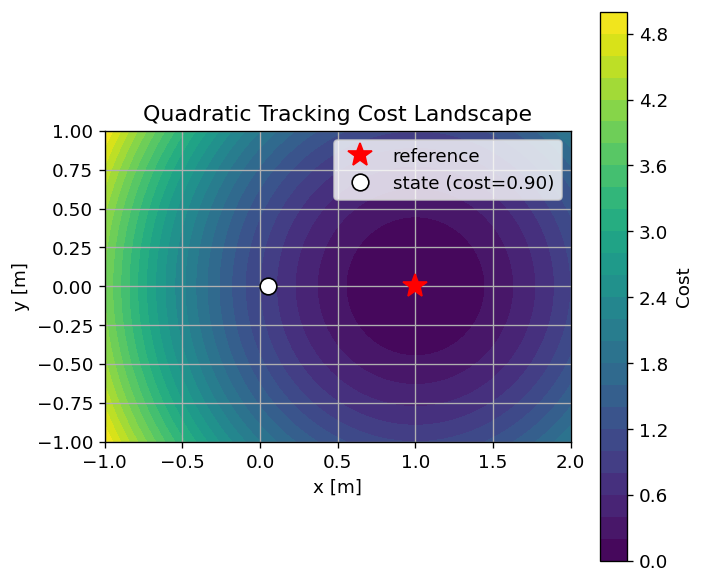

In [ ]:
def stage_cost(state, reference):
    "Quadratic position tracking cost."
    pos_error = state[:2] - reference[:2]
    return jnp.sum(pos_error**2)

# Test
ref = jnp.array([1.0, 0.0, 0.0, 1.0])
c = stage_cost(state_1, ref)
print(f"Cost from {state_1[:2]} to ref {ref[:2]}: {c:.4f}")

# Plot the cost landscape
fig, ax = plt.subplots(figsize=(6, 5))

# Grid of positions
xs = jnp.linspace(-1, 2, 100)
ys = jnp.linspace(-1, 1, 100)
X, Y = jnp.meshgrid(xs, ys)

# Evaluate cost at each grid point (only position matters)
costs = (X - ref[0])**2 + (Y - ref[1])**2

contour = ax.contourf(X, Y, costs, levels=30, cmap='viridis')
plt.colorbar(contour, ax=ax, label='Cost')

ax.plot(ref[0], ref[1], 'r*', markersize=15, label='reference')
ax.plot(float(state_1[0]), float(state_1[1]), 'wo', markersize=10,
        markeredgecolor='k', label=f'state (cost={c:.2f})')

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Quadratic Tracking Cost Landscape')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


---
## Section 2 -- `jax.jit`: Compilation

### Concept

`jax.jit` compiles a Python function into optimized machine code via XLA. The first call *traces* the function (records operations on abstract shapes), compiles it, and caches the result. Subsequent calls skip Python entirely and run the compiled version.

In [ ]:
# A simple function -- no JIT
def slow_fn(x):
    for _ in range(10):
        x = jnp.sin(x) + 0.01 * x
    return x

# JIT-compiled version
fast_fn = jit(slow_fn)

x = jnp.ones(100_000)

# Warm up (first call includes compilation time)
_ = fast_fn(x)

# Time comparison
n_runs = 100

start = time.perf_counter()
for _ in range(n_runs):
    _ = slow_fn(x).block_until_ready()
t_slow = (time.perf_counter() - start) / n_runs * 1000

start = time.perf_counter()
for _ in range(n_runs):
    _ = fast_fn(x).block_until_ready()
t_fast = (time.perf_counter() - start) / n_runs * 1000

print(f"Without jit: {t_slow:.3f} ms per call")
print(f"With jit:    {t_fast:.3f} ms per call")
print(f"Speedup:     {t_slow/t_fast:.1f}x")

Without jit: 4.543 ms per call
With jit:    0.111 ms per call
Speedup:     41.0x


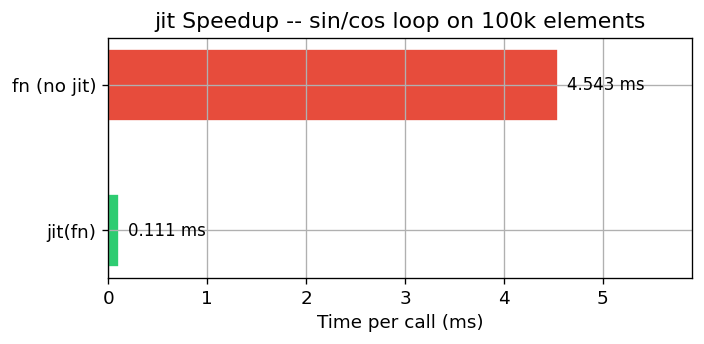

In [ ]:
# Visualize the speedup
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(['jit(fn)', 'fn (no jit)'], [t_fast, t_slow],
               color=['#2ecc71', '#e74c3c'], edgecolor='white', height=0.5)
ax.set_xlabel('Time per call (ms)')
ax.set_title('jit Speedup -- sin/cos loop on 100k elements')
for bar, t in zip(bars, [t_fast, t_slow]):
    ax.text(bar.get_width() + 0.02 * t_slow, bar.get_y() + bar.get_height()/2,
            f'{t:.3f} ms', va='center', fontsize=10)
ax.set_xlim(0, t_slow * 1.3)
plt.tight_layout()
plt.show()

### Gotchas: Tracing and Control Flow

When JAX traces your function, it sees **abstract shapes**, not concrete values. This means Python control flow that depends on array *values* will fail:
| Pattern | Problem | Fix |
|---|---|---|
| `if x > 0:` on a traced array | Can't branch on abstract value | `jax.lax.cond(x > 0, true_fn, false_fn, x)` |
| `for i in range(n)` where `n` is large & fixed | Unrolls the loop into the graph (slow compile) | `jax.lax.scan` (next section!) |
| Changing input shapes between calls | Triggers recompilation each time | Keep shapes static; pad if needed |

#### Gotcha 1: Python if on a traced value

In [ ]:
def clamp_speed_bad(state):
    "Clamp velocity to [0, 5] — BROKEN under jit."
    v = state[3]
    if v > 5.0:       # Python if on a traced JAX value!
        v = 5.0
    elif v < 0.0:
        v = 0.0
    return state.at[3].set(v)

try:
    jit(clamp_speed_bad)(state_0)
except Exception as e:
    print(f"ERROR: {type(e).__name__}")
    print(f"  {str(e)[:120]}...")

ERROR: TracerBoolConversionError
  Attempted boolean conversion of traced array with shape bool[].
The error occurred while tracing the function clamp_spee...


In [ ]:
# Fix: use jax.lax.cond, jnp.where, or jnp.clip
def clamp_speed_good(state):
    "Clamp velocity to [0, 5] — works under jit."
    v = jnp.clip(state[3], 0.0, 5.0)   # jnp.clip is trace-safe
    return state.at[3].set(v)

result = jit(clamp_speed_good)(state_0)
print(f"\nFixed version: v clamped to {result[3]:.2f}")


Fixed version: v clamped to 1.00


In [ ]:
# You can also use jnp.where for more complex branching:
def relu_dynamics(state):
    "Zero out negative velocities."
    v = jnp.where(state[3] > 0, state[3], 0.0)  # trace-safe if/else
    return state.at[3].set(v)

print(f"jnp.where version: {jit(relu_dynamics)(state_0)[3]:.2f}")

jnp.where version: 1.00


#### Gotcha 2: Changing input shapes triggers recompilation

In [ ]:
# Notice @jit decorator for auto-jitting on call
@jit
def sum_squares(x):
    return jnp.sum(x**2)

# First call: compiles for shape (100,)
_ = sum_squares(jnp.ones(100))

# Each new shape recompiles — watch the timings
import time
for n in [100, 200, 300, 100]:
    x = jnp.ones(n)
    start = time.perf_counter()
    _ = sum_squares(x).block_until_ready()
    elapsed = (time.perf_counter() - start) * 1000
    print(f"  shape ({n:3d},): {elapsed:6.2f} ms  {'(recompile!)' if elapsed > 1.0 else '(cached)'}")

print("========================================")
print("Running AFTER cached compilation")
for n in [100, 200, 300, 100]:
    x = jnp.ones(n)
    start = time.perf_counter()
    _ = sum_squares(x).block_until_ready()
    elapsed = (time.perf_counter() - start) * 1000
    print(f"  shape ({n:3d},): {elapsed:6.2f} ms  {'(recompile!)' if elapsed > 1.0 else '(cached)'}")

  shape (100,):   0.16 ms  (cached)
  shape (200,):  72.41 ms  (recompile!)
  shape (300,):  85.13 ms  (recompile!)
  shape (100,):   0.26 ms  (cached)
Running AFTER cached compilation
  shape (100,):   0.16 ms  (cached)
  shape (200,):   0.26 ms  (cached)
  shape (300,):   0.21 ms  (cached)
  shape (100,):   0.21 ms  (cached)



Notice: shape (100,) is fast the second time (cached), but 200 and 300 each pay
a compilation cost. In a control loop, keep your array shapes FIXED (or compile ALL possible shapes BEFOREHAND)

### MPPI Application: Compile the Dynamics Step

Let's compile our bicycle model and measure the difference:

In [ ]:
dynamics_jit = jit(dynamics)

# Warm up
_ = dynamics_jit(state_0, control_0)

n_runs = 100

start = time.perf_counter()
for _ in range(n_runs):
    _ = dynamics(state_0, control_0).block_until_ready()
t_nojit = (time.perf_counter() - start) / n_runs * 1e6

start = time.perf_counter()
for _ in range(n_runs):
    _ = dynamics_jit(state_0, control_0).block_until_ready()
t_jit = (time.perf_counter() - start) / n_runs * 1e6

print(f"dynamics (no jit): {t_nojit:.1f} us")
print(f"dynamics (jit):    {t_jit:.1f} us")
print(f"Speedup:           {t_nojit/t_jit:.1f}x")

dynamics (no jit): 3001.0 us
dynamics (jit):    108.5 us
Speedup:           27.7x


---
## Section 3 -- `jax.lax.scan`: Compiled Loops

### Concept

Many robotics computations are **sequential**: state at time $t+1$ depends on state at time $t$. A Python `for` loop works, but it gets unrolled at trace time, meaning JAX builds a separate operation node for every iteration. `lax.scan` gives you a single compiled loop.

```python
final_carry, stacked_outputs = lax.scan(step_fn, init_carry, xs)
```

- `step_fn(carry, x) -> (new_carry, output)` -- one iteration
- `init_carry` -- initial loop state
- `xs` -- array to iterate over (one slice per step)
- Returns: final carry + all outputs stacked

In [ ]:
# Minimal example: cumulative sum via scan
def cumsum_step(running_total, x_t):
    new_total = running_total + x_t
    return new_total, new_total   # (new_carry, output)

xs = jnp.array([1.0, 2.0, 3.0, 4.0, 5.0])
final, cumsum = lax.scan(cumsum_step, 0.0, xs)

print(f"Input:          {xs}")
print(f"Cumulative sum: {cumsum}")
print(f"Final carry:    {final}")

Input:          [1. 2. 3. 4. 5.]
Cumulative sum: [ 1.  3.  6. 10. 15.]
Final carry:    15.0


### MPPI Application: Roll Out a Trajectory

A single MPPI rollout propagates the bicycle model over a horizon of $H$ steps given a control sequence. Each step depends on the previous state, exactly what `scan` is for:

In [ ]:
def rollout(state_init, controls):
    "Roll out bicycle model over a control sequence. Returns (H, 4) trajectory."
    def step(state, u):
        next_state = dynamics(state, u)
        return next_state, next_state   # carry forward + store

    _, trajectory = lax.scan(step, state_init, controls)
    return trajectory

# Test: constant slight steering for 40 steps
H = 40
controls_test = jnp.tile(jnp.array([0.15, 0.5]), (H, 1))
traj = rollout(state_0, controls_test)
print(f"Trajectory shape: {traj.shape}")  # (40, 4)
print(f"Final position:   x={traj[-1, 0]:.2f}, y={traj[-1, 1]:.2f}")

Trajectory shape: (40, 4)
Final position:   x=2.17, y=1.70


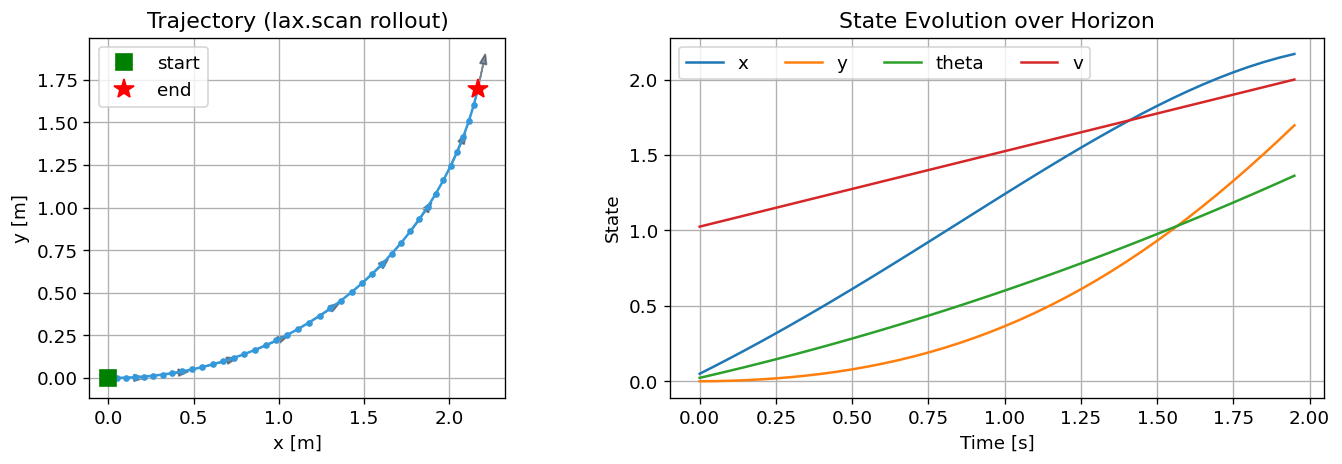

In [ ]:
# Visualize the trajectory
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# XY path
ax = axes[0]
full_traj = jnp.vstack([state_0[None, :], traj])
ax.plot(full_traj[:, 0], full_traj[:, 1], 'o-', markersize=3, color='#3498db')
ax.plot(full_traj[0, 0], full_traj[0, 1], 'gs', markersize=10, label='start')
ax.plot(full_traj[-1, 0], full_traj[-1, 1], 'r*', markersize=12, label='end')
# Draw heading arrows every 5 steps
for i in range(0, len(full_traj), 5):
    dx = 0.15 * jnp.cos(full_traj[i, 2])
    dy = 0.15 * jnp.sin(full_traj[i, 2])
    ax.arrow(float(full_traj[i, 0]), float(full_traj[i, 1]),
             float(dx), float(dy), head_width=0.04, color='#2c3e50', alpha=0.6)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Trajectory (lax.scan rollout)')
ax.legend()
ax.set_aspect('equal')

# State evolution over time
ax = axes[1]
t = jnp.arange(H) * DT
ax.plot(t, traj[:, 0], label='x')
ax.plot(t, traj[:, 1], label='y')
ax.plot(t, traj[:, 2], label='theta')
ax.plot(t, traj[:, 3], label='v')
ax.set_xlabel('Time [s]')
ax.set_ylabel('State')
ax.set_title('State Evolution over Horizon')
ax.legend(ncol=4, loc='upper left')

plt.tight_layout()
plt.show()

**Timing: `lax.scan` vs Python for-loop**

In [ ]:
def rollout_python_loop(state_init, controls):
    "Same rollout, but with a plain Python for-loop."
    states = []
    state = state_init
    for t in range(controls.shape[0]):
        state = dynamics(state, controls[t])
        states.append(state)
    return jnp.stack(states)

# Compile the scan version
rollout_jit = jit(rollout)
_ = rollout_jit(state_0, controls_test)  # warm up

n_runs = 100

start = time.perf_counter()
for _ in range(n_runs):
    _ = rollout_python_loop(state_0, controls_test).block_until_ready()
t_loop = (time.perf_counter() - start) / n_runs * 1e6

start = time.perf_counter()
for _ in range(n_runs):
    _ = rollout_jit(state_0, controls_test).block_until_ready()
t_scan = (time.perf_counter() - start) / n_runs * 1e6

print(f"Python for-loop:   {t_loop:.0f} us")
print(f"jit(lax.scan):     {t_scan:.0f} us")
print(f"Speedup:           {t_loop/t_scan:.1f}x")

Python for-loop:   152151 us
jit(lax.scan):     719 us
Speedup:           211.7x


Generally, you would use numpy with (optionally) numba to compute such for loops, so let's compare with that for a more realistic scenario

In [ ]:
# ── NumPy version of dynamics + rollout ──
import numpy as np

def dynamics_np(state, control, dt=DT):
    "Kinematic bicycle model in pure NumPy."
    x, y, theta, v = state
    delta, a = control
    return np.array([
        x + v * np.cos(theta) * dt,
        y + v * np.sin(theta) * dt,
        theta + (v / L) * np.tan(delta) * dt,
        v + a * dt,
    ])

def rollout_numpy(state_init, controls):
    "Rollout with NumPy — the way you'd normally write it."
    states = []
    state = np.array(state_init, dtype=np.float32)
    for t in range(len(controls)):
        state = dynamics_np(state, controls[t])
        states.append(state)
    return np.stack(states)

# ── Numba-jitted version ──
from numba import njit

@njit(cache=True)
def dynamics_numba(state, control, dt=DT):
    x, y, theta, v = state[0], state[1], state[2], state[3]
    delta, a = control[0], control[1]
    return np.array([
        x + v * np.cos(theta) * dt,
        y + v * np.sin(theta) * dt,
        theta + (v / L) * np.tan(delta) * dt,
        v + a * dt,
    ], dtype=np.float32)

@njit(cache=True)
def rollout_numba(state_init, controls):
    H = controls.shape[0]
    states = np.empty((H, 4), dtype=np.float32)
    state = state_init.copy()
    for t in range(H):
        state = dynamics_numba(state, controls[t])
        states[t] = state
    return states

# Convert to numpy for fair comparison
state_0_np = np.array(state_0, dtype=np.float32)
controls_test_np = np.array(controls_test, dtype=np.float32)

# Warm up all versions
_ = rollout_jit(state_0, controls_test)            # JAX (scan)
_ = rollout_numpy(state_0_np, controls_test_np)    # NumPy
_ = rollout_numba(state_0_np, controls_test_np)    # Numba

# Verify all produce the same result
traj_jax   = rollout_jit(state_0, controls_test)
traj_np    = rollout_numpy(state_0_np, controls_test_np)
traj_numba = rollout_numba(state_0_np, controls_test_np)
print(f"JAX vs NumPy match:  {np.allclose(traj_jax, traj_np, atol=1e-5)}")
print(f"JAX vs Numba match:  {np.allclose(traj_jax, traj_numba, atol=1e-5)}")

# ── Timing ──
n_runs = 100

start = time.perf_counter()
for _ in range(n_runs):
    _ = rollout_numpy(state_0_np, controls_test_np)
t_numpy = (time.perf_counter() - start) / n_runs * 1e6

start = time.perf_counter()
for _ in range(n_runs):
    _ = rollout_numba(state_0_np, controls_test_np)
t_numba = (time.perf_counter() - start) / n_runs * 1e6

start = time.perf_counter()
for _ in range(n_runs):
    _ = rollout_jit(state_0, controls_test).block_until_ready()
t_scan = (time.perf_counter() - start) / n_runs * 1e6

print(f"\nNumPy for-loop:     {t_numpy:.0f} µs")
print(f"Numba @njit:        {t_numba:.0f} µs")
print(f"JAX jit(lax.scan):  {t_scan:.0f} µs")
print(f"\nNumba wins on a single rollout! But wait until we vmap over 1024 rollouts...")

JAX vs NumPy match:  True
JAX vs Numba match:  True

NumPy for-loop:     601 µs
Numba @njit:        10 µs
JAX jit(lax.scan):  1063 µs

Numba wins on a single rollout! But wait until we vmap over 1024 rollouts...


### Alternative: `lax.scan` vs `lax.fori_loop`

Both `scan` and `fori_loop` compile a sequential loop into XLA. The difference is what they return:
- **`scan`** — automatically stacks per-step outputs into an array (convenient for trajectories)
- **`fori_loop`** — only returns the final carry (you manage storage yourself)

If you only need the final state, `fori_loop` avoids output-stacking overhead entirely. If you need the full trajectory, `fori_loop` requires manual `.at[t].set()`, which can still be faster since you control the storage layout. The main downside is how easy they are to write. For larger problems, lax.scan may scale better.

In [ ]:
# ── fori_loop: full trajectory ──
def rollout_fori(state_init, controls):
    "Rollout via fori_loop — manual trajectory storage."
    H = controls.shape[0]
    trajectory = jnp.zeros((H, 4))

    def body(t, carry):
        state, traj = carry
        next_state = dynamics(state, controls[t])
        traj = traj.at[t].set(next_state)
        return (next_state, traj)

    _, trajectory = lax.fori_loop(0, H, body, (state_init, trajectory))
    return trajectory

# ── fori_loop: final state only ──
def rollout_fori_final(state_init, controls):
    "Only returns the final state — no trajectory stored."
    def body(t, state):
        return dynamics(state, controls[t])
    return lax.fori_loop(0, controls.shape[0], body, state_init)

# Compile and warm up
rollout_fori_jit = jit(rollout_fori)
rollout_fori_final_jit = jit(rollout_fori_final)
_ = rollout_fori_jit(state_0, controls_test)
_ = rollout_fori_final_jit(state_0, controls_test)

# Verify correctness
traj_scan = rollout_jit(state_0, controls_test)
traj_fori = rollout_fori_jit(state_0, controls_test)
final_fori = rollout_fori_final_jit(state_0, controls_test)
print(f"scan vs fori trajectory match: {jnp.allclose(traj_scan, traj_fori)}")
print(f"fori final state matches last row: {jnp.allclose(traj_scan[-1], final_fori)}")

# ── Timing ──
n_runs = 100

start = time.perf_counter()
for _ in range(n_runs):
    _ = rollout_jit(state_0, controls_test).block_until_ready()
t_scan = (time.perf_counter() - start) / n_runs * 1e6

start = time.perf_counter()
for _ in range(n_runs):
    _ = rollout_fori_jit(state_0, controls_test).block_until_ready()
t_fori = (time.perf_counter() - start) / n_runs * 1e6

start = time.perf_counter()
for _ in range(n_runs):
    _ = rollout_fori_final_jit(state_0, controls_test).block_until_ready()
t_fori_final = (time.perf_counter() - start) / n_runs * 1e6

print(f"\nlax.scan (full trajectory):       {t_scan:.0f} µs")
print(f"lax.fori_loop (full trajectory):  {t_fori:.0f} µs")
print(f"lax.fori_loop (final state only): {t_fori_final:.0f} µs")
print(f"\nfori_loop is {t_scan/t_fori:.1f}x faster for full trajectory")
print(f"fori_loop is {t_scan/t_fori_final:.1f}x faster when you only need the final state")

scan vs fori trajectory match: True
fori final state matches last row: True

lax.scan (full trajectory):       1164 µs
lax.fori_loop (full trajectory):  644 µs
lax.fori_loop (final state only): 921 µs

fori_loop is 1.8x faster for full trajectory
fori_loop is 1.3x faster when you only need the final state


---
## Section 4 -- `jax.vmap`: Automatic Vectorization

### Concept

`jax.vmap` takes a function that operates on **one example** and returns a function that operates on a **batch** with no manual reshaping, no extra batch dimensions in your math.

In [ ]:
# Simple example: norm of a single vector
def norm(x):
    return jnp.sqrt(jnp.sum(x**2))

# Batch it
norm_batched = vmap(norm)

key = jax.random.PRNGKey(42)
points = jax.random.normal(key, (6, 3))

# Without vmap -- you need a loop
norms_loop = jnp.array([norm(points[i]) for i in range(len(points))])

# With vmap -- one line
norms_vmap = norm_batched(points)

print(f"Points shape: {points.shape}")
print(f"Norms (loop): {norms_loop}")
print(f"Norms (vmap): {norms_vmap}")
print(f"Match: {jnp.allclose(norms_loop, norms_vmap)}")

Points shape: (6, 3)
Norms (loop): [0.55358243 0.29328507 1.7086029  1.5084578  1.8060526  1.0890285 ]
Norms (vmap): [0.55358243 0.29328507 1.7086029  1.5084578  1.8060526  1.0890285 ]
Match: True


**`in_axes` controls which arguments get batched:**

```python
vmap(f, in_axes=(0, None))  # batch 1st arg over axis 0, broadcast 2nd arg
```

In [ ]:
# Distance from N points to a SINGLE reference
def dist(point, ref):
    return jnp.linalg.norm(point - ref)

# Batch over points (axis 0), same ref for all (None)
batched_dist = vmap(dist, in_axes=(0, None))

ref = jnp.array([0.0, 0.0, 0.0])
dists = batched_dist(points, ref)
print(f"Distances to origin: {dists}")

Distances to origin: [0.55358243 0.29328507 1.7086029  1.5084578  1.8060526  1.0890285 ]


### MPPI Application: Parallel Rollouts

MPPI samples $K$ noise perturbations and rolls out $K$ trajectories **independently**. We already have `rollout()` for a single trajectory. With `vmap`, we parallelize across all $K$ samples:

In [ ]:
def rollout_with_noise(state, nominal_controls, noise):
    "Single rollout with perturbed controls."
    perturbed = nominal_controls + noise
    return rollout(state, perturbed)

# vmap over noise (axis 0), broadcast state and nominal_controls
batched_rollout = vmap(rollout_with_noise, in_axes=(None, None, 0))

# Setup: K=1024 rollouts, H=40 horizon
K = 1024
H = 40
key = jax.random.PRNGKey(99)
nominal = jnp.zeros((H, 2))  # start from zero nominal
noise_samples = jax.random.normal(key, (K, H, 2)) * jnp.array([0.15, 0.8])

# Run all K rollouts in parallel
all_trajectories = batched_rollout(state_0, nominal, noise_samples)
print(f"Trajectories shape: {all_trajectories.shape}")  # (K, H, 4)

Trajectories shape: (1024, 40, 4)


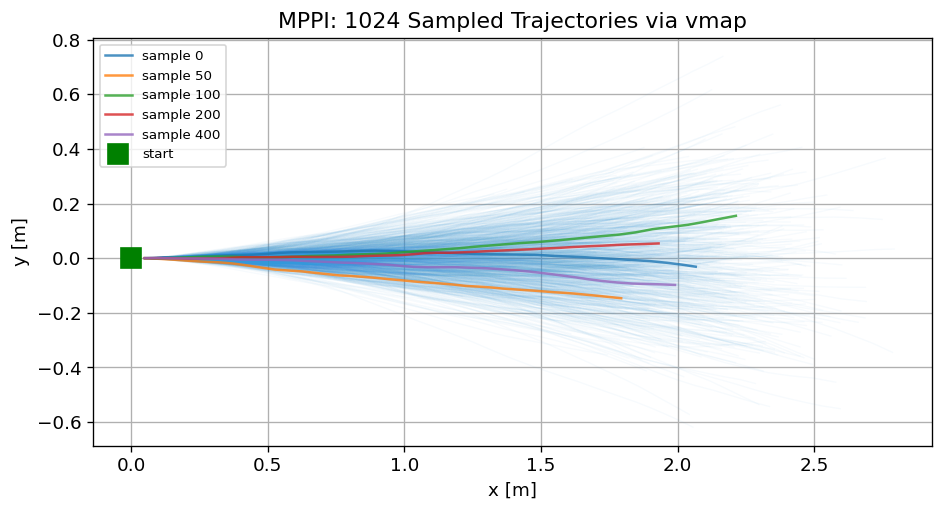

In [ ]:
# Visualize all sampled trajectories
fig, ax = plt.subplots(figsize=(8, 6))

# Plot all K trajectories with low alpha
for k in range(K):
    ax.plot(all_trajectories[k, :, 0], all_trajectories[k, :, 1],
            alpha=0.04, color='#3498db', linewidth=0.8)

# Highlight a few random ones
for k in [0, 50, 100, 200, 400]:
    ax.plot(all_trajectories[k, :, 0], all_trajectories[k, :, 1],
            alpha=0.8, linewidth=1.5, label=f'sample {k}')

ax.plot(state_0[0], state_0[1], 'gs', markersize=12, label='start', zorder=5)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title(f'MPPI: {K} Sampled Trajectories via vmap')
ax.legend(fontsize=8, loc='upper left')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

**Timing: vmap vs Python loop over rollouts**

In [ ]:
# Compiled batched version
batched_rollout_jit = jit(batched_rollout)
_ = batched_rollout_jit(state_0, nominal, noise_samples)  # warm up

# Python loop version: roll out one at a time
rollout_jit_single = jit(rollout_with_noise)
_ = rollout_jit_single(state_0, nominal, noise_samples[0])  # warm up

n_runs = 100
# n_runs = 1 # Change to n_runs = 1 when running 100024 samples

start = time.perf_counter()
for _ in range(n_runs):
    trajs = []
    for k in range(K):
        trajs.append(rollout_jit_single(state_0, nominal, noise_samples[k]))
    _ = jnp.stack(trajs).block_until_ready()
t_loop = (time.perf_counter() - start) / n_runs * 1000

start = time.perf_counter()
for _ in range(n_runs):
    _ = batched_rollout_jit(state_0, nominal, noise_samples).block_until_ready()
t_vmap = (time.perf_counter() - start) / n_runs * 1000

print(f"Python loop ({K} rollouts):  {t_loop:.1f} ms")
print(f"jit(vmap(...)):              {t_vmap:.2f} ms")
print(f"Speedup:                     {t_loop/t_vmap:.0f}x")

Python loop (1024 rollouts):  1542.9 ms
jit(vmap(...)):              0.67 ms
Speedup:                     2305x


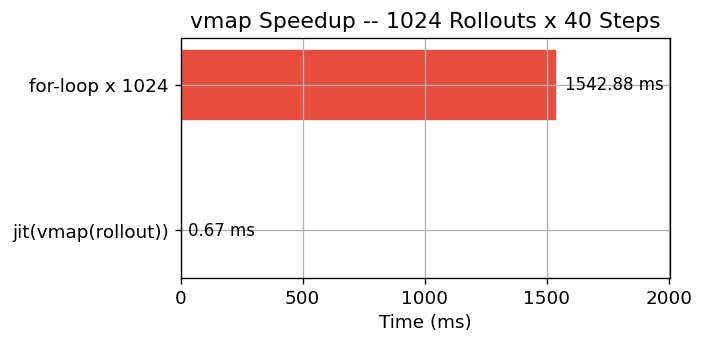

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(['jit(vmap(rollout))', f'for-loop x {K}'],
               [t_vmap, t_loop],
               color=['#2ecc71', '#e74c3c'], edgecolor='white', height=0.5)
ax.set_xlabel('Time (ms)')
ax.set_title(f'vmap Speedup -- {K} Rollouts x {H} Steps')
for bar, t in zip(bars, [t_vmap, t_loop]):
    ax.text(bar.get_width() + 0.02 * t_loop, bar.get_y() + bar.get_height()/2,
            f'{t:.2f} ms', va='center', fontsize=10)
ax.set_xlim(0, t_loop * 1.3)
plt.tight_layout()
plt.show()

**Timing: vmap vs Numba parallel loops**

In [ ]:
from numba import njit, prange

@njit(parallel=True, cache=True)
def rollout_numba_batch(state_init, controls_batch):
    "K parallel rollouts via Numba prange."
    K = controls_batch.shape[0]
    H = controls_batch.shape[1]
    all_trajs = np.empty((K, H, 4), dtype=np.float32)
    for k in prange(K):
        state = state_init.copy()
        for t in range(H):
            state = dynamics_numba(state, controls_batch[k, t])
            all_trajs[k, t] = state
    return all_trajs

# Prepare batched controls
controls_batch_np = np.array(nominal + noise_samples, dtype=np.float32)
state_0_np = np.array(state_0, dtype=np.float32)

# Warm up
_ = rollout_numba_batch(state_0_np, controls_batch_np)

# Time it
n_runs = 100
# n_runs = 1 # change n_runs to 1 when running with 10024 samples

start = time.perf_counter()
for _ in range(n_runs):
    _ = rollout_numba_batch(state_0_np, controls_batch_np)
t_numba_batch = (time.perf_counter() - start) / n_runs * 1000

print(f"Numba prange ({K} rollouts):  {t_numba_batch:.2f} ms")
print(f"JAX jit(vmap) ({K} rollouts): {t_vmap:.2f} ms")
print(f"JAX is {t_numba_batch/t_vmap:.1f}x times faster!")

Numba prange (1024 rollouts):  2.58 ms
JAX jit(vmap) (1024 rollouts): 0.67 ms
JAX is 3.9x times faster!


---
## Section 5 -- Composing Transforms: The Full MPPI Pipeline

### Concept

JAX transforms are **composable** -- you can stack `jit`, `vmap`, `grad`, `scan` in any order:

```python
jit(vmap(grad(f)))  # compiled, batched gradients in one line
```

The general pattern for robotics:
1. Write the function for **one sample, one timestep**
2. `lax.scan` over time -> one rollout
3. `vmap` over samples -> batched rollouts
4. `jit` the whole thing -> fully compiled

We have already been doing this! Let's now assemble the **complete MPPI controller**.

In [ ]:
# --- MPPI Parameters ---
K = 1024         # number of samples
H = 40           # horizon length
SIGMA_STEER = 0.15
SIGMA_ACCEL = 0.8
LAMBDA = 1.0     # temperature parameter

# Reference: drive to a goal point
goal = jnp.array([3.0, 1.5])

def stage_cost_mppi(state, goal):
    "Position tracking cost for MPPI."
    return jnp.sum((state[:2] - goal)**2)

def terminal_cost(state, goal):
    "Extra penalty at the end of the horizon."
    return 5.0 * jnp.sum((state[:2] - goal)**2)

# --- Single rollout cost ---
def rollout_cost(state_init, controls, goal):
    "Cost of a single rollout."
    traj = rollout(state_init, controls)  # (H, 4) -- uses lax.scan inside
    stage_costs = vmap(stage_cost_mppi, in_axes=(0, None))(traj, goal)
    return jnp.sum(stage_costs) + terminal_cost(traj[-1], goal)

# --- Full MPPI step (compiled) ---
@jit
def mppi_step(state, nominal_controls, key, goal):
    "One MPPI update -- fully compiled."
    # 1. Sample noise
    noise = jax.random.normal(key, (K, H, 2)) * jnp.array([SIGMA_STEER, SIGMA_ACCEL])

    # 2 & 3. Cost of each perturbed rollout
    def sample_cost(eps):
        return rollout_cost(state, nominal_controls + eps, goal)

    costs = vmap(sample_cost)(noise)           # (K,)

    # 4. Importance weights (softmax)
    weights = jax.nn.softmax(-costs / LAMBDA)  # (K,)

    # 5. Weighted update
    update = jnp.sum(weights[:, None, None] * noise, axis=0)  # (H, 2)
    new_nominal = nominal_controls + update

    return new_nominal, costs

In [ ]:
# --- Run MPPI in a receding-horizon loop ---
state = jnp.array([0.0, 0.0, 0.0, 1.0])  # start: origin, heading east, v=1
nominal = jnp.zeros((H, 2))
key = jax.random.PRNGKey(0)

n_steps = 60
trajectory_history = [state]
control_history = []
cost_history = []

for t in range(n_steps):
    key, subkey = jax.random.split(key)

    # MPPI update
    nominal, costs = mppi_step(state, nominal, subkey, goal)
    cost_history.append(float(jnp.min(costs)))

    # Apply first control
    u = nominal[0]
    control_history.append(u)
    state = dynamics(state, u)
    trajectory_history.append(state)

    # Shift nominal controls (warm start)
    nominal = jnp.concatenate([nominal[1:], nominal[-1:]], axis=0)

trajectory_history = jnp.stack(trajectory_history)
control_history = jnp.stack(control_history)
print(f"Final position: ({trajectory_history[-1, 0]:.2f}, {trajectory_history[-1, 1]:.2f})")
print(f"Goal:           ({goal[0]:.2f}, {goal[1]:.2f})")

Final position: (2.92, 1.46)
Goal:           (3.00, 1.50)


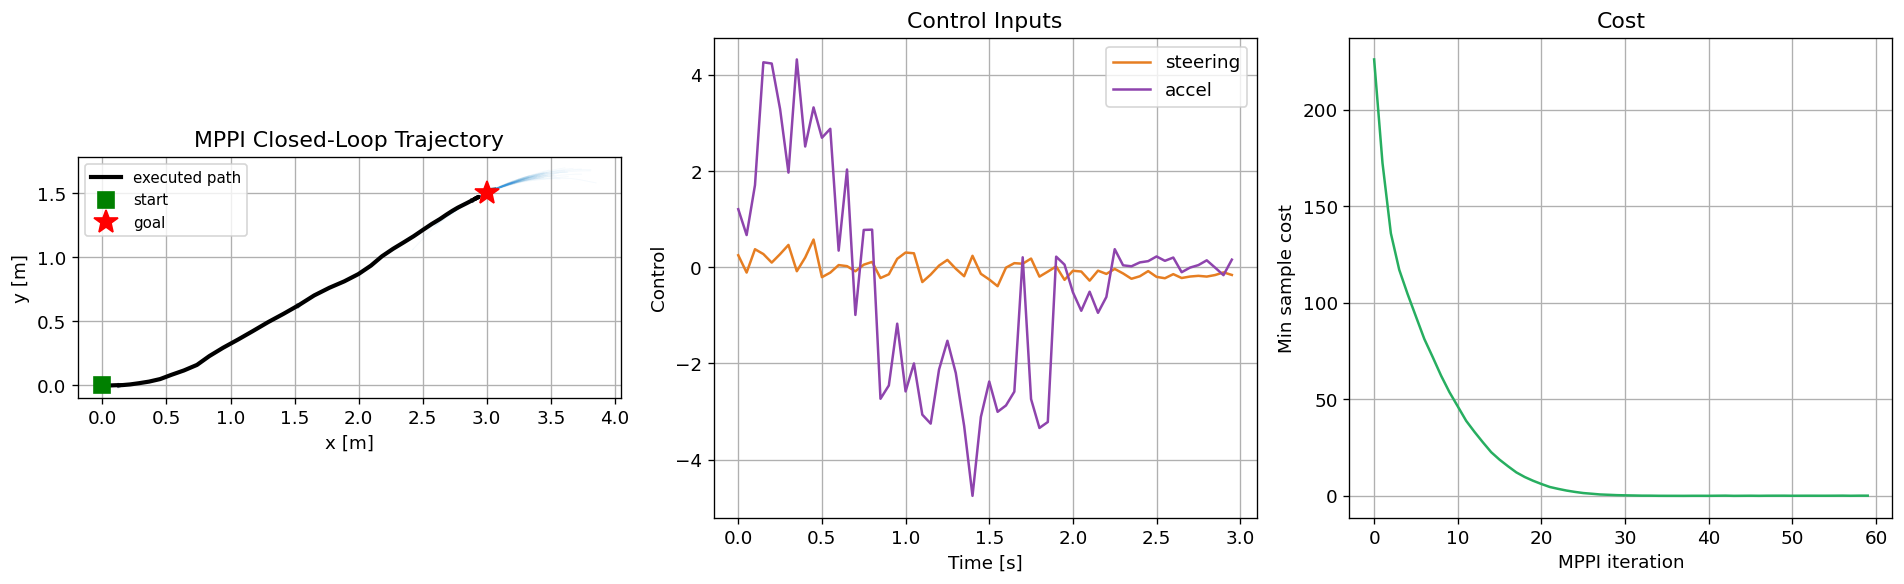

In [ ]:
# --- Visualize MPPI results ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. XY Trajectory with sampled rollouts from the final state
ax = axes[0]
noise_viz = jax.random.normal(jax.random.PRNGKey(123), (200, H, 2)) * jnp.array([SIGMA_STEER, SIGMA_ACCEL])
for k in range(200):
    viz_traj = rollout(trajectory_history[-1], nominal + noise_viz[k])
    ax.plot(viz_traj[:, 0], viz_traj[:, 1], alpha=0.05, color="#3498db", linewidth=0.5)

ax.plot(trajectory_history[:, 0], trajectory_history[:, 1],
        'k-', linewidth=2.5, label='executed path', zorder=4)
ax.plot(trajectory_history[0, 0], trajectory_history[0, 1], 'gs', markersize=10, label='start', zorder=5)
ax.plot(goal[0], goal[1], 'r*', markersize=15, label='goal', zorder=5)
# heading arrows
for i in range(0, len(trajectory_history), 16):
    s = trajectory_history[i]
    dx, dy = 0.12 * jnp.cos(s[2]), 0.12 * jnp.sin(s[2])
    ax.arrow(float(s[0]), float(s[1]), float(dx), float(dy),
             head_width=0.03, color='#2c3e50', alpha=0.7)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('MPPI Closed-Loop Trajectory')
ax.legend(fontsize=9)
ax.set_aspect('equal')

# 2. Controls over time
ax = axes[1]
t_ax = jnp.arange(n_steps) * DT
ax.plot(t_ax, control_history[:, 0], label='steering', color='#e67e22')
ax.plot(t_ax, control_history[:, 1], label='accel', color='#8e44ad')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Control')
ax.set_title('Control Inputs')
ax.legend()

# 3. Min cost over iterations
ax = axes[2]
ax.plot(cost_history, color='#27ae60')
ax.set_xlabel('MPPI iteration')
ax.set_ylabel('Min sample cost')
ax.set_title('Cost')

plt.tight_layout()
plt.show()

### Timing the Full Pipeline

How fast is our complete MPPI step? This is the number that matters for real-time control.

In [ ]:
# Time the full MPPI step
key = jax.random.PRNGKey(0)
_ = mppi_step(state_0, jnp.zeros((H, 2)), key, goal)  # warm up

n_runs = 100
# n_runs = 1 # Change n_runs when running with 10024 samples

start = time.perf_counter()
for i in range(n_runs):
    key, subkey = jax.random.split(key)
    result = mppi_step(state_0, jnp.zeros((H, 2)), subkey, goal)
    result[0].block_until_ready()
t_mppi = (time.perf_counter() - start) / n_runs * 1000

print(f"Full MPPI step ({K} samples x {H} horizon): {t_mppi:.2f} ms")
print(f"Achievable rate: {1000/t_mppi:.0f} Hz")
print(f"F1TENTH target:  >= 20 Hz {"pass" if 1000/t_mppi >= 20 else "FAIL"}")

Full MPPI step (1024 samples x 40 horizon): 1.91 ms
Achievable rate: 524 Hz
F1TENTH target:  >= 20 Hz pass


---
## Section 6 -- `jax.grad`: Automatic Differentiation

### Concept

`jax.grad` differentiates a **scalar-valued** Python function. `jax.jacobian` handles **vector-valued** functions.

In [ ]:
# grad: scalar function -> gradient function
def f(x):
    return jnp.sum(x**3)

df = grad(f)
x = jnp.array([1.0, 2.0, 3.0])
print(f"f(x)     = {f(x)}")
print(f"grad(f)  = {df(x)}")           # [3x^2] = [3, 12, 27]
print(f"expected = {3 * x**2}")

f(x)     = 36.0
grad(f)  = [ 3. 12. 27.]
expected = [ 3. 12. 27.]


In [ ]:
# value_and_grad: get both at once (common in optimization)
val, g = value_and_grad(f)(x)
print(f"value = {val}, grad = {g}")

value = 36.0, grad = [ 3. 12. 27.]


In [ ]:
# jacobian: for vector -> vector functions
def g(x):
    return jnp.array([x[0]**2 + x[1], jnp.sin(x[0]) * x[1]])

J = jacobian(g)
x0 = jnp.array([1.0, 2.0])
print(f"g(x0) = {g(x0)}")
print(f"Jacobian:\n{J(x0)}")

g(x0) = [3.       1.682942]
Jacobian:
[[2.        1.       ]
 [1.0806046 0.841471 ]]


### Beyond MPPI: Free Jacobians for MPC Linearization

MPPI is sampling-based and does not need gradients. But MPC does -- it needs the **linearized dynamics** $A = \partial f / \partial x$ and $B = \partial f / \partial u$ at each operating point. With JAX, you get these from the same `dynamics` function we defined in Section 1:

In [ ]:
# A = d(dynamics)/d(state),  B = d(dynamics)/d(control)
A_fn = jit(jacobian(dynamics, argnums=0))
B_fn = jit(jacobian(dynamics, argnums=1))

# Evaluate at a specific operating point
state_op = jnp.array([1.0, 0.5, 0.3, 2.0])
control_op = jnp.array([0.1, 0.0])

A = A_fn(state_op, control_op)
B = B_fn(state_op, control_op)

print("A (df/dx) -- 4x4 state Jacobian:")
print(A)
print(f"\nB (df/du) -- 4x2 input Jacobian:")
print(B)

A (df/dx) -- 4x4 state Jacobian:
[[ 1.          0.         -0.02955202  0.04776683]
 [ 0.          1.          0.09553365  0.01477601]
 [ 0.          0.          1.          0.01520222]
 [ 0.          0.          0.          1.        ]]

B (df/du) -- 4x2 input Jacobian:
[[0.         0.        ]
 [0.         0.        ]
 [0.30608094 0.        ]
 [0.         0.05      ]]


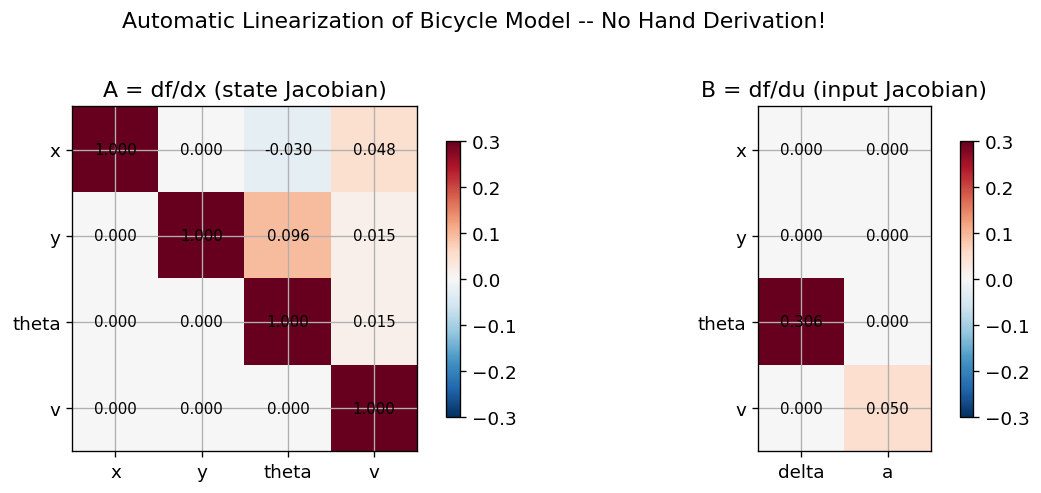

In [ ]:
# Visualize the Jacobian structure
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

state_labels = ['x', 'y', 'theta', 'v']
control_labels = ['delta', 'a']

ax = axes[0]
im = ax.imshow(np.array(A), cmap='RdBu_r', aspect='equal', vmin=-0.3, vmax=0.3)
ax.set_xticks(range(4)); ax.set_xticklabels(state_labels)
ax.set_yticks(range(4)); ax.set_yticklabels(state_labels)
ax.set_title('A = df/dx (state Jacobian)')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{A[i,j]:.3f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)

ax = axes[1]
im = ax.imshow(np.array(B), cmap='RdBu_r', aspect='equal', vmin=-0.3, vmax=0.3)
ax.set_xticks(range(2)); ax.set_xticklabels(control_labels)
ax.set_yticks(range(4)); ax.set_yticklabels(state_labels)
ax.set_title('B = df/du (input Jacobian)')
for i in range(4):
    for j in range(2):
        ax.text(j, i, f'{B[i,j]:.3f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Automatic Linearization of Bicycle Model -- No Hand Derivation!', y=1.02)
plt.tight_layout()
plt.show()

**Key takeaway:** If you change the dynamics model (e.g., add tire slip, drag, or a different vehicle), the Jacobians update automatically. No re-derivation needed.

---
## Cheat Sheet

### Transform Quick Reference

| Transform | What it does | Typical robotics use |
|---|---|---|
| `jit(f)` | Compile `f` via XLA | Any hot-path function |
| `vmap(f, in_axes)` | Vectorize `f` over a batch dim | Parallel rollouts, batched collision checks |
| `grad(f)` | Gradient of scalar `f` | Cost optimization, MPC |
| `jacobian(f, argnums)` | Jacobian of vector `f` | Dynamics linearization (A, B matrices) |
| `lax.scan(f, init, xs)` | Compiled sequential loop | Trajectory rollout, time-stepping |

### Common Gotchas

| Gotcha | Symptom | Fix |
|---|---|---|
| Mutating arrays | `TypeError` | Use `.at[i].set(v)` |
| Global RNG state | Doesn't exist in JAX | `jax.random.PRNGKey` + split |
| `if` on traced value | `ConcretizationTypeError` | `jax.lax.cond` |
| Long Python for-loop in jitted code | Slow compile / huge trace | `lax.scan` |
| Changing input shapes | Recompilation each call | Pad to fixed shapes |
| Expecting `float64` | Silent precision loss | `jax.config.update("jax_enable_x64", True)` |

### Links

- [JAX Quickstart](https://docs.jax.dev/en/latest/notebooks/thinking_in_jax.html)
- [JAX - The Sharp Bits](https://docs.jax.dev/en/latest/notebooks/Common_Gotchas_in_JAX.html)
- [`jax.lax.scan` docs](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html)
- [JAX FAQ -- Sharp Bits](https://docs.jax.dev/en/latest/notebooks/Common_Gotchas_in_JAX.html)